In [110]:
import uproot
import pandas as pd
import numpy as np
import glob


In [111]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.style.use('belle2')

import os

In [112]:
import glob

# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_241220_Ks_massconst"
base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_241220_Ks_nomassconst"
base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/phipip/MC15rd_phipip_loose_v7_1_250106_Pip_p_cut_test"

cm_elements = ["15rd_phi_e7_18_4S_v3", "15rd_phi_e20_b26_v1", "15rd_phi_e20_e26_4S_v2", "15rd_phi_e21_5S_scan_v1", "15rd_phi_mori_off_v1"]
cut_expression = "Dp_isSignal == 1"
cut_expression = "Dp_M>0"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/etapip_gg/phi/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file["phi"]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_isSignal','Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge','Ks_Pip_genMotherID','Ks_Pim_genMotherID','Ks_Pip_genMotherPDG','Ks_Pim_genMotherPDG','Dp_mcPDG','Pip_genMotherID','Pip_genMotherPDG']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

# Concatenate all DataFrames into a single DataFrame
# df_bkg = pd.concat(dataframes, ignore_index=True)

# df_bkg = df_bkg.query('Dp_isSignal!=1')
# df_bkg = df_bkg.query('(Pip_genMotherID!=etapip_Eta_genMotherID) | abs(Pip_genMotherPDG)!=431 | abs(etapip_Eta_genMotherPDG)!=431')

In [113]:
df_bkg = pd.concat(dataframes, ignore_index=True)


In [114]:
# df_bkg = df_bkg.query('num_Dstar_no_nan>0')
df_bkg = df_bkg.query('Pip_p>0.4')
# df_bkg = df_bkg.query('Pip_pionID<0.01')

# df_bkg = df_bkg.query('Dp_M> 1.7 & Dp_M<2.1')
# df_bkg = df_bkg.query('Dp_M> 1.8 & Dp_M<2.05')

In [115]:
df_bkg.describe()

,Dp_isSignal,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,Ks_Pip_genMotherID,Ks_Pim_genMotherID,Ks_Pip_genMotherPDG,Ks_Pim_genMotherPDG,Dp_mcPDG,Pip_genMotherID,Pip_genMotherPDG
count,1610696.0,1.623129e+06,1.623129e+06,1.623129e+06,1.623129e+06,1.623129e+06,1.623129e+06,1.623129e+06,1.623129e+06,1.623129e+06,1.610696e+06,1.623129e+06,1.623129e+06
mean,0.0,1.921319e+00,1.537672e-01,3.602689e-01,1.379113e+00,-2.889481e-04,1.068258e+01,1.064910e+01,4.842240e+03,4.615013e+03,9.332042e+02,1.059047e+01,1.355367e+04
std,0.0,8.754521e-02,5.096869e-01,4.671919e-01,6.516017e-01,1.000000e+00,6.296422e+00,6.390974e+00,2.061758e+05,2.047237e+05,1.672815e+04,6.617745e+00,3.487010e+05
min,0.0,1.600000e+00,-9.970459e-01,-9.063730e-01,4.000035e-01,-1.000000e+00,0.000000e+00,0.000000e+00,-2.042300e+04,-1.002130e+05,-2.043300e+04,0.000000e+00,-1.002130e+05
25%,0.0,1.871235e+00,-2.620869e-01,2.404980e-02,8.457787e-01,-1.000000e+00,7.000000e+00,7.000000e+00,-4.310000e+02,-4.310000e+02,-4.310000e+02,7.000000e+00,-4.310000e+02
50%,0.0,1.966138e+00,2.193876e-01,4.689051e-01,1.275737e+00,-1.000000e+00,9.000000e+00,9.000000e+00,3.330000e+02,3.330000e+02,2.300000e+01,9.000000e+00,2.300000e+01
75%,0.0,1.969951e+00,5.992093e-01,7.619627e-01,1.810171e+00,1.000000e+00,1.400000e+01,1.400000e+01,4.310000e+02,4.310000e+02,4.310000e+02,1.400000e+01,4.310000e+02
max,0.0,2.099994e+00,9.999812e-01,9.818186e-01,4.408781e+00,1.000000e+00,7.600000e+01,8.100000e+01,9.020221e+06,9.020221e+06,3.005530e+05,8.300000e+01,9.010221e+06


In [116]:
nan_columns = df_bkg.isnull().any()
print(nan_columns)

Dp_isSignal             True
Dp_M                   False
Dp_CMS_cosTheta        False
Pip_cosTheta           False
Pip_p                  False
Pip_charge             False
Ks_Pip_genMotherID     False
Ks_Pim_genMotherID     False
Ks_Pip_genMotherPDG    False
Ks_Pim_genMotherPDG    False
Dp_mcPDG                True
Pip_genMotherID        False
Pip_genMotherPDG       False
dtype: bool


In [117]:
columns_to_convert = ['Ks_Pip_genMotherID', 'Ks_Pim_genMotherID', 'Pip_genMotherID', 
                      'Ks_Pim_genMotherPDG', 'Ks_Pip_genMotherPDG', 'Pip_genMotherPDG', 'Dp_mcPDG']

for col in columns_to_convert:
    df_bkg[col] = pd.to_numeric(df_bkg[col], errors='coerce').fillna(0).astype(int)


In [118]:
# df_generic_matched = df_bkg.query('Dp_isSignal==1')
df_generic_matched = df_bkg.query('Ks_Pip_genMotherID==Ks_Pim_genMotherID & Ks_Pip_genMotherID==Pip_genMotherID')
df_generic_matched = df_bkg.query('(Ks_Pim_genMotherPDG==431 | Ks_Pim_genMotherPDG==-431) & (Ks_Pip_genMotherPDG==431 | Ks_Pip_genMotherPDG==-431 )')
df_generic_matched = df_bkg.query('(Pip_genMotherPDG == 431 | Pip_genMotherPDG == -431)')
df_generic_matched = df_bkg.query('(Dp_mcPDG == 431 | Dp_mcPDG == -431)')

# df_generic_matched = df_bkg.query('Dp_M>0')


In [119]:
df_generic_matched.head()

,Dp_isSignal,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,Ks_Pip_genMotherID,Ks_Pim_genMotherID,Ks_Pip_genMotherPDG,Ks_Pim_genMotherPDG,Dp_mcPDG,Pip_genMotherID,Pip_genMotherPDG
1,0.0,1.966104,0.872766,0.611268,0.420733,-1.0,6,6,-431,-431,-431,6,-431
2,0.0,1.966228,0.675401,0.560912,1.978694,1.0,7,7,431,431,431,7,431
3,0.0,1.971820,0.025122,-0.126100,1.246149,-1.0,17,17,-431,-431,-431,17,-431
9,0.0,1.967796,0.352438,0.199853,1.745269,-1.0,6,6,-431,-431,-431,6,-431
12,0.0,1.967871,0.029119,0.555769,1.314633,1.0,3,3,431,431,431,3,431


In [120]:
df_generic_matched = df_bkg.query('Dp_M>1.93 & Dp_M<2.01')


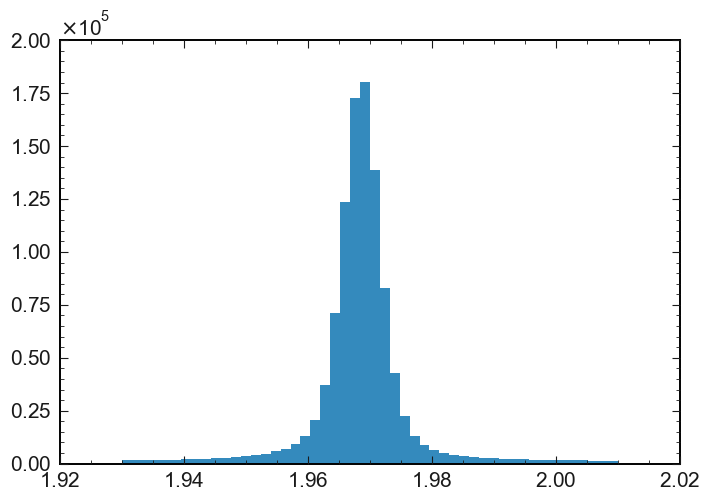

In [121]:
plt.hist(df_generic_matched.Dp_M,bins=np.linspace(1.93,2.01,51));
# plt.hist(df_generic_matched.Dp_M);

In [122]:
base_path_sig = "/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC"
elements_sig = ["Dsptoetapip_gg", "Dsptoetapip_gg_cc"]
# project_name = "241129_loose_v3"
project_name = "241213_loose_v7"

file_list_sig = []
for element in elements_sig:
    # pattern = f"{base_path_sig}/{element}/{project_name}/*.root"
    pattern = f"{base_path_sig}/{element}/{project_name}/etapip_gg/*BCS.root"

    file_list_sig += glob.glob(pattern)

In [123]:
dataframes_signal = []
# cut_expression = "Dp_isSignal == 1"  # Replace with your actual cut condition
cut_expression = "Dp_M>0"  # Replace with your actual cut condition

for file_name in file_list_sig:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file["etapip_gg"]

    # Specify the branches you want to extract
    #branches = ['Dp_Psum','dM_pi0_mask_nonan','dM_pi0_mask_2_nonan','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_Easym","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan","etapip_Eta_daughterDiffOfPhi_0_1","etapip_Eta_daughterAngle_0_1"]  # Replace with actual branch names
    # branches = ['Dp_Psum','dM_pi0_mask','dM_pi0_mask_2','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_Easym","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan","etapip_Eta_daughterDiffOfPhi_0_1","etapip_Eta_daughterAngle_0_1"]  # Replace with actual branch names
    # branches = ['Pip_pionID','Dp_Psum','dM_pi0_mask_nonan','dM_pi0_mask_2_nonan','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_Easym","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan","etapip_Eta_daughterDiffOfPhi_0_1","etapip_Eta_daughterAngle_0_1"]  # Replace with actual branch names
    branches = ['Dp_isSignal','Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes_signal.append(df_temp)


df_signal = pd.concat(dataframes_signal, ignore_index=True)


In [124]:
# df_signal = df_signal.query('num_Dstar_no_nan>0')
# df_signal = df_signal.query('Pip_pionID<0.01')
df_signal = df_signal.query('Pip_genMotherID==etapip_Eta_genMotherID')
df_signal = df_signal.query('Pip_genMotherPDG==431 | Pip_genMotherPDG==-431')
df_signal = df_signal.query('Pip_p>0.4')


In [125]:
df_signal.head()

,Dp_isSignal,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,Pip_genMotherID,etapip_Eta_genMotherID,Pip_genMotherPDG
1,0.0,1.971917,-0.024021,0.814331,1.254918,1.0,8.0,8.0,431.0
3,0.0,1.955449,-0.300442,0.139089,0.776253,1.0,3.0,3.0,431.0
4,0.0,1.961627,0.332157,0.769996,0.965283,1.0,10.0,10.0,431.0
5,0.0,1.962405,0.606902,0.919116,0.753188,1.0,6.0,6.0,431.0
6,0.0,1.964422,0.011579,0.485585,2.380620,1.0,3.0,3.0,431.0


In [126]:
unique_values = df_signal['Pip_genMotherPDG'].unique()
print(unique_values)

[ 431. -431.]


In [127]:
nan_columns = df_signal.isnull().any()
print(nan_columns)

Dp_isSignal               False
Dp_M                      False
Dp_CMS_cosTheta           False
Pip_cosTheta              False
Pip_p                     False
Pip_charge                False
Pip_genMotherID           False
etapip_Eta_genMotherID    False
Pip_genMotherPDG          False
dtype: bool


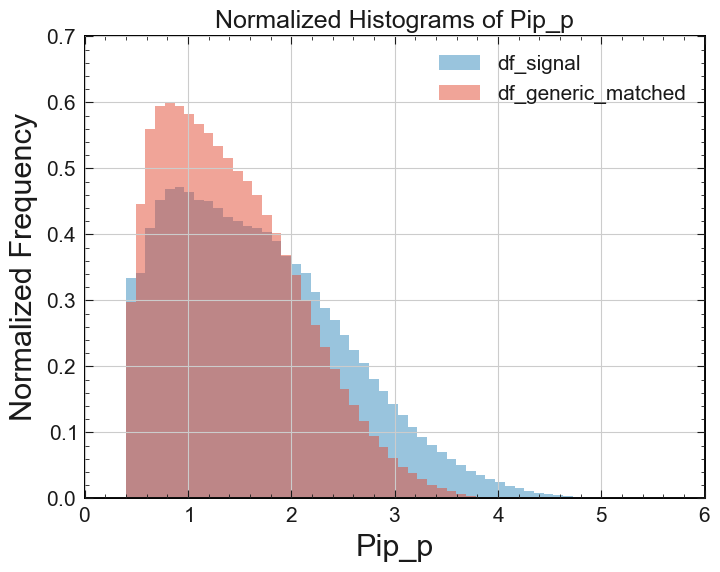

In [128]:
# Define range and bins
range_min, range_max = 0.4, 5.1
bins = 50

# Plot normalized histograms
plt.figure(figsize=(8, 6))

plt.hist(
    df_signal['Pip_p'], 
    bins=bins, 
    range=(range_min, range_max), 
    density=True, 
    alpha=0.5, 
    label='df_signal'
)

plt.hist(
    df_generic_matched['Pip_p'], 
    bins=bins, 
    range=(range_min, range_max), 
    density=True, 
    alpha=0.5, 
    label='df_generic_matched'
)

# Add labels and legend
plt.xlabel('Pip_p')
plt.ylabel('Normalized Frequency')
plt.title('Normalized Histograms of Pip_p')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [129]:
from plothist import make_hist, plot_hist
# import matplotlib.pyplot as plt
from plothist import plot_two_hist_comparison


In [130]:
tree_to_compare = "etapip_gg"

In [131]:
plt.rcParams['font.family'] = 'DejaVu Sans'


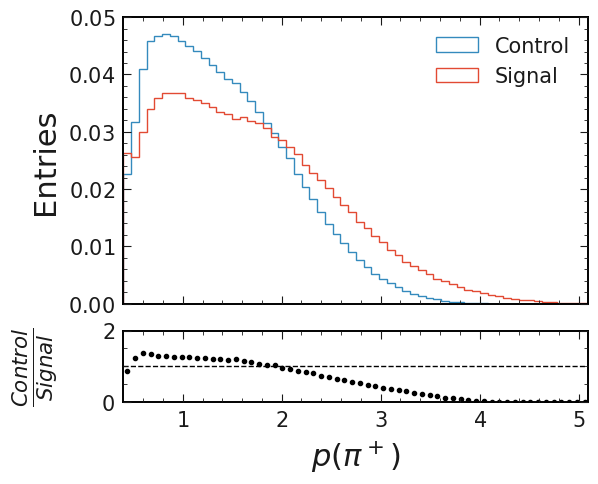

In [132]:
name = "Pip_p"
category = "category"
xlabel = r"$p(\pi^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_generic_matched[name]
x2 = df_signal[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
x_range = (min(min(x1), min(x2)),5.1)

h1 = make_hist(x1, bins=60, range=x_range, weights=1/len(x1))
h2 = make_hist(x2, bins=60, range=x_range, weights=1/len(x2))


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Control",
    h2_label="Signal",
)

fig.savefig(f"MC15rd_{tree_to_compare}_{name}_nomassconst.png", bbox_inches="tight")

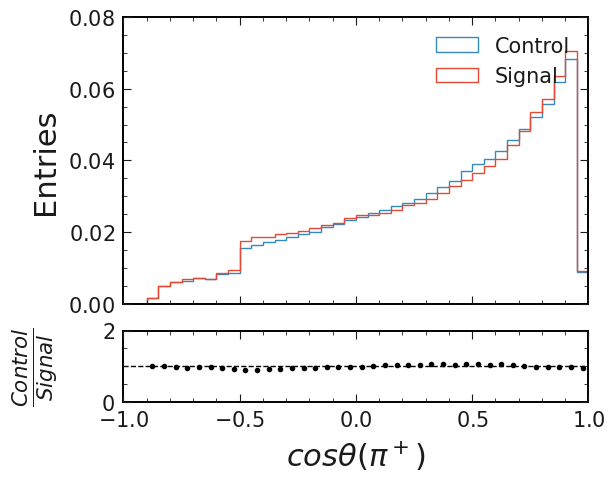

In [133]:
name = "Pip_cosTheta"
category = "category"
xlabel = r"$cos\theta(\pi^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_generic_matched[name]
x2 = df_signal[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
x_range = (-1,1)

h1 = make_hist(x1, bins=40, range=x_range, weights=1/len(x1))
h2 = make_hist(x2, bins=40, range=x_range, weights=1/len(x2))


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Control",
    h2_label="Signal",
)

fig.savefig(f"MC15rd_{tree_to_compare}_{name}_nomassconst.png", bbox_inches="tight")

In [134]:
from plothist import (
    create_variable_registry,
    update_variable_registry_ranges,
    get_variable_from_registry,
)
# custom_dict = {"legend_location" : 'upper left'}
# create_variable_registry(custom_dict=custom_dict)

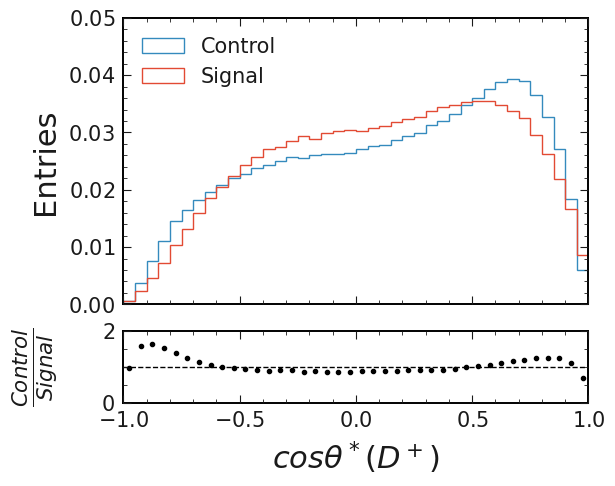

In [135]:
name = "Dp_CMS_cosTheta"
category = "category"
xlabel = r"$cos\theta^*(D^+)$"


x1 = df_generic_matched[name]
x2 = df_signal[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
x_range = (-1,1)

h1 = make_hist(x1, bins=40, range=x_range, weights=1/len(x1))
h2 = make_hist(x2, bins=40, range=x_range, weights=1/len(x2))


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Control",
    h2_label="Signal",
)
# fig.legend(loc="upper left")
ax_main.legend(loc="upper left") 
fig.savefig(f"MC15rd_{tree_to_compare}_{name}_nomassconst.png", bbox_inches="tight")